# Spotify Wrapped 2025 – Relatório Exploratório
### *Análise Global de Streaming*

![Spotify Foto](images/spotify-photo.png)

## 1. Resumo
Este relatório busca apresentar uma análise do ecossistema do Spotify em 2025.

**Objetivo:** Apresentar as análises que serão conduzidas.

## Índice



## 2. Carregamento dos Dados
**Objetivo:** Importar os dados necessários e realizar uma inspeção inicial (perfilamento) para entender o formato, quantidade de registros e colunas disponíveis, estabelecendo uma base sólida para a análise.

Foram utilizados três conjuntos de dados principais para construir uma visão holística:
-   `df_alltime`: Dados históricos de referência (Top 100 de todos os tempos).
-   `df_artistas_2025`: Métricas no nível do artista para o ano atual.
-   `df_songs_2025`: Métricas de desempenho (streams, características de áudio) para as 50 principais faixas de 2025.

### Importando as bibliotecas

É necessário importar bibliotecas para realizar análises e representar os dados em gráficos.


In [26]:
# Importar bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import warnings

### Configuração do ambiente visual

Configuração do ambiente para que os gráficos apresentados fiquem no formato desejado.


In [27]:
# Configuração do ambiente visual

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (12, 6)

### Carregando dados

Carregamento dos dados do dataset "Spotify Wrapped 2025 | Top Songs & Artists".


In [28]:
# Carregando os dados

try:
    df_alltime = pd.read_csv('data/spotify_alltime_top100_songs.csv')
    df_artistas_2025 = pd.read_csv('data/spotify_wrapped_2025_top50_artists.csv')
    df_musicas_2025 = pd.read_csv('data/spotify_wrapped_2025_top50_songs.csv')
    print("Sucesso: Conjuntos de dados carregados.")
except Exception as e:
    print(f"Erro ao carregar os conjuntos de dados: {e}")

# Perfilamento inicial dos dados
for name, df in [("Todos os Tempos", df_alltime), ("Artistas 2025", df_artistas_2025), ("Músicas 2025", df_musicas_2025)]:
    print(f"\n--- Perfil {name} ---")
    print(f"Formato (Shape): {df.shape}")
    display(df.describe(include='all').T.head(5))

Sucesso: Conjuntos de dados carregados.

--- Perfil Todos os Tempos ---
Formato (Shape): (100, 14)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
alltime_rank,100.0,NaN,NaN,NaN,50.5,29.011492,1.0,25.75,50.5,75.25,100.0
song_title,100,100,Blinding Lights,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
artist,100,80,Ed Sheeran,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_streams_billions,100.0,NaN,NaN,NaN,2.5246,0.851432,1.4,1.735,2.435,3.1675,5.26
primary_genre,100,39,Pop,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- Perfil Artistas 2025 ---
Formato (Shape): (50, 11)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
wrapped_2025_rank,50.0,NaN,NaN,NaN,25.5,14.57738,1.0,13.25,25.5,37.75,50.0
artist_name,50,49,Laufey,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_listeners_millions_mar2026,50.0,NaN,NaN,NaN,54.178,19.36649,27.6,40.125,51.35,64.475,110.4
primary_genre,50,30,Pop,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,50,12,USA,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- Perfil Músicas 2025 ---
Formato (Shape): (50, 16)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
wrapped_2025_rank,50.0,NaN,NaN,NaN,25.5,14.57738,1.0,13.25,25.5,37.75,50.0
song_title,50,50,Die With A Smile,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
artist,50,35,Sabrina Carpenter,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
streams_2025_billions,50.0,NaN,NaN,NaN,0.9294,0.303022,0.56,0.6925,0.845,1.1125,1.7
primary_genre,50,23,Pop,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Limpeza e tratamento dos dados
**Objetivo:** Garantir a qualidade e a integridade dos dados, identificando valores ausentes, dados duplicados e criando novas métricas para enriquecer a análise. Uma análise de nível sênior exige verificações rigorosas.

O foco é:
1.  **Avaliação de Valores Ausentes**: Identificar lacunas que poderiam viesar as distribuições.
2.  **Verificação de Duplicatas**: Assegurar que não há registros repetidos.
3.  **Métricas Derivadas**: Criar indicadores que avaliam a "eficiência".
4.  **Análise de Outliers**: Checar se há Outliers entre os dados fornecidos.

            Tabela  Contagem_Nulos
0  Todos os Tempos               0
1    Artistas_2025               0
2     Musicas_2025               0


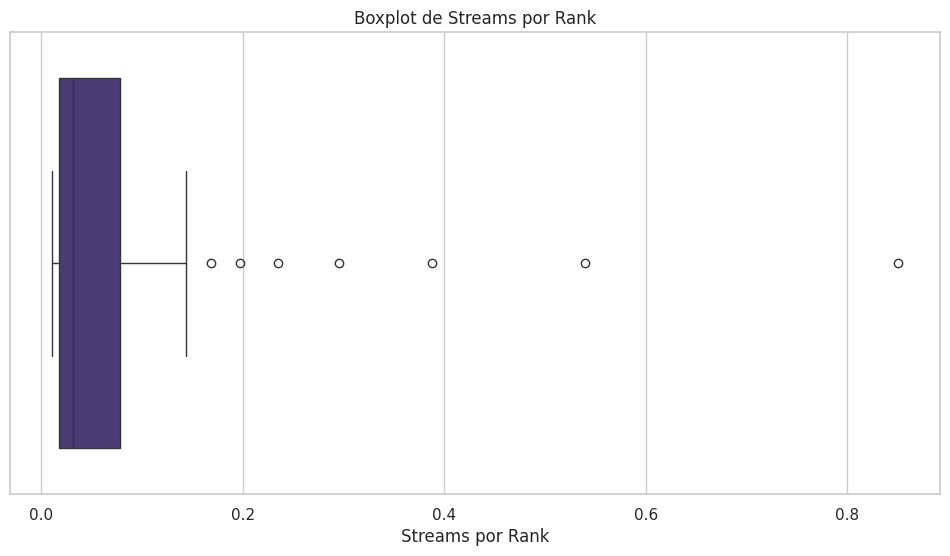

In [29]:

 # 1. Avaliação de Nulos (Ausentes)
missing_report = pd.DataFrame({
    'Tabela': ['Todos os Tempos', 'Artistas_2025', 'Musicas_2025'],
    'Contagem_Nulos': [df_alltime.isnull().sum().sum(), df_artistas_2025.isnull().sum().sum(), df_musicas_2025.isnull().sum().sum()]
})
print(missing_report)


# 2. Verificação de Duplicatas
for name, df in [("Todos os Tempos", df_alltime), ("Artistas 2025", df_artistas_2025), ("Músicas 2025", df_musicas_2025)]:
    dups = df.duplicated().sum()
    if dups > 0:
        print(f"Aviso: {dups} duplicatas encontradas em {name}. Removendo...")
        df.drop_duplicates(inplace=True)
# Caso não apresente dados de duplicatas, o código acima não fará alterações.

# 3. Métricas Derivadas: "Eficiência" do Artista
# Quantos streams um artista gera por posição no ranking? Relação entre volume de streams e posição no ranking.
df_musicas_2025['stream_por_rank'] = df_musicas_2025['streams_2025_billions'] / (df_musicas_2025['wrapped_2025_rank'] + 1)


# 4. Análise de Outliers: Streams por Rank
sns.boxplot(x=df_musicas_2025['stream_por_rank'])
plt.title('Boxplot de Streams por Rank')
plt.xlabel('Streams por Rank')
plt.show()

**Resultado das checagens:**
- Não foram encontrados valores nulos nos conjuntos analisados.
- O boxplot sinaliza a presença de outliers em `stream_por_rank`, mas eles parecem refletir variação real dos dados e foram mantidos na análise.

Termos técnicos desta etapa:
- `Outlier`: observação muito distante do padrão geral dos dados.
- `Boxplot`: gráfico que resume distribuição, mediana, quartis e possíveis outliers.

# Análise Exploratória de Dados
**Objetivo:** Explorar os dados visualmente para entender distribuições, tendências e relações entre as variáveis.

## 4. Análise: Distribuição do Sucesso
**Objetivo:** Analisar as variáveis individualmente para entender a distribuição do volume de streaming, a dominância de gêneros e as tendências temporais.

Primeiramente, examina-se a distribuição das principais características de áudio e do volume de streamings.

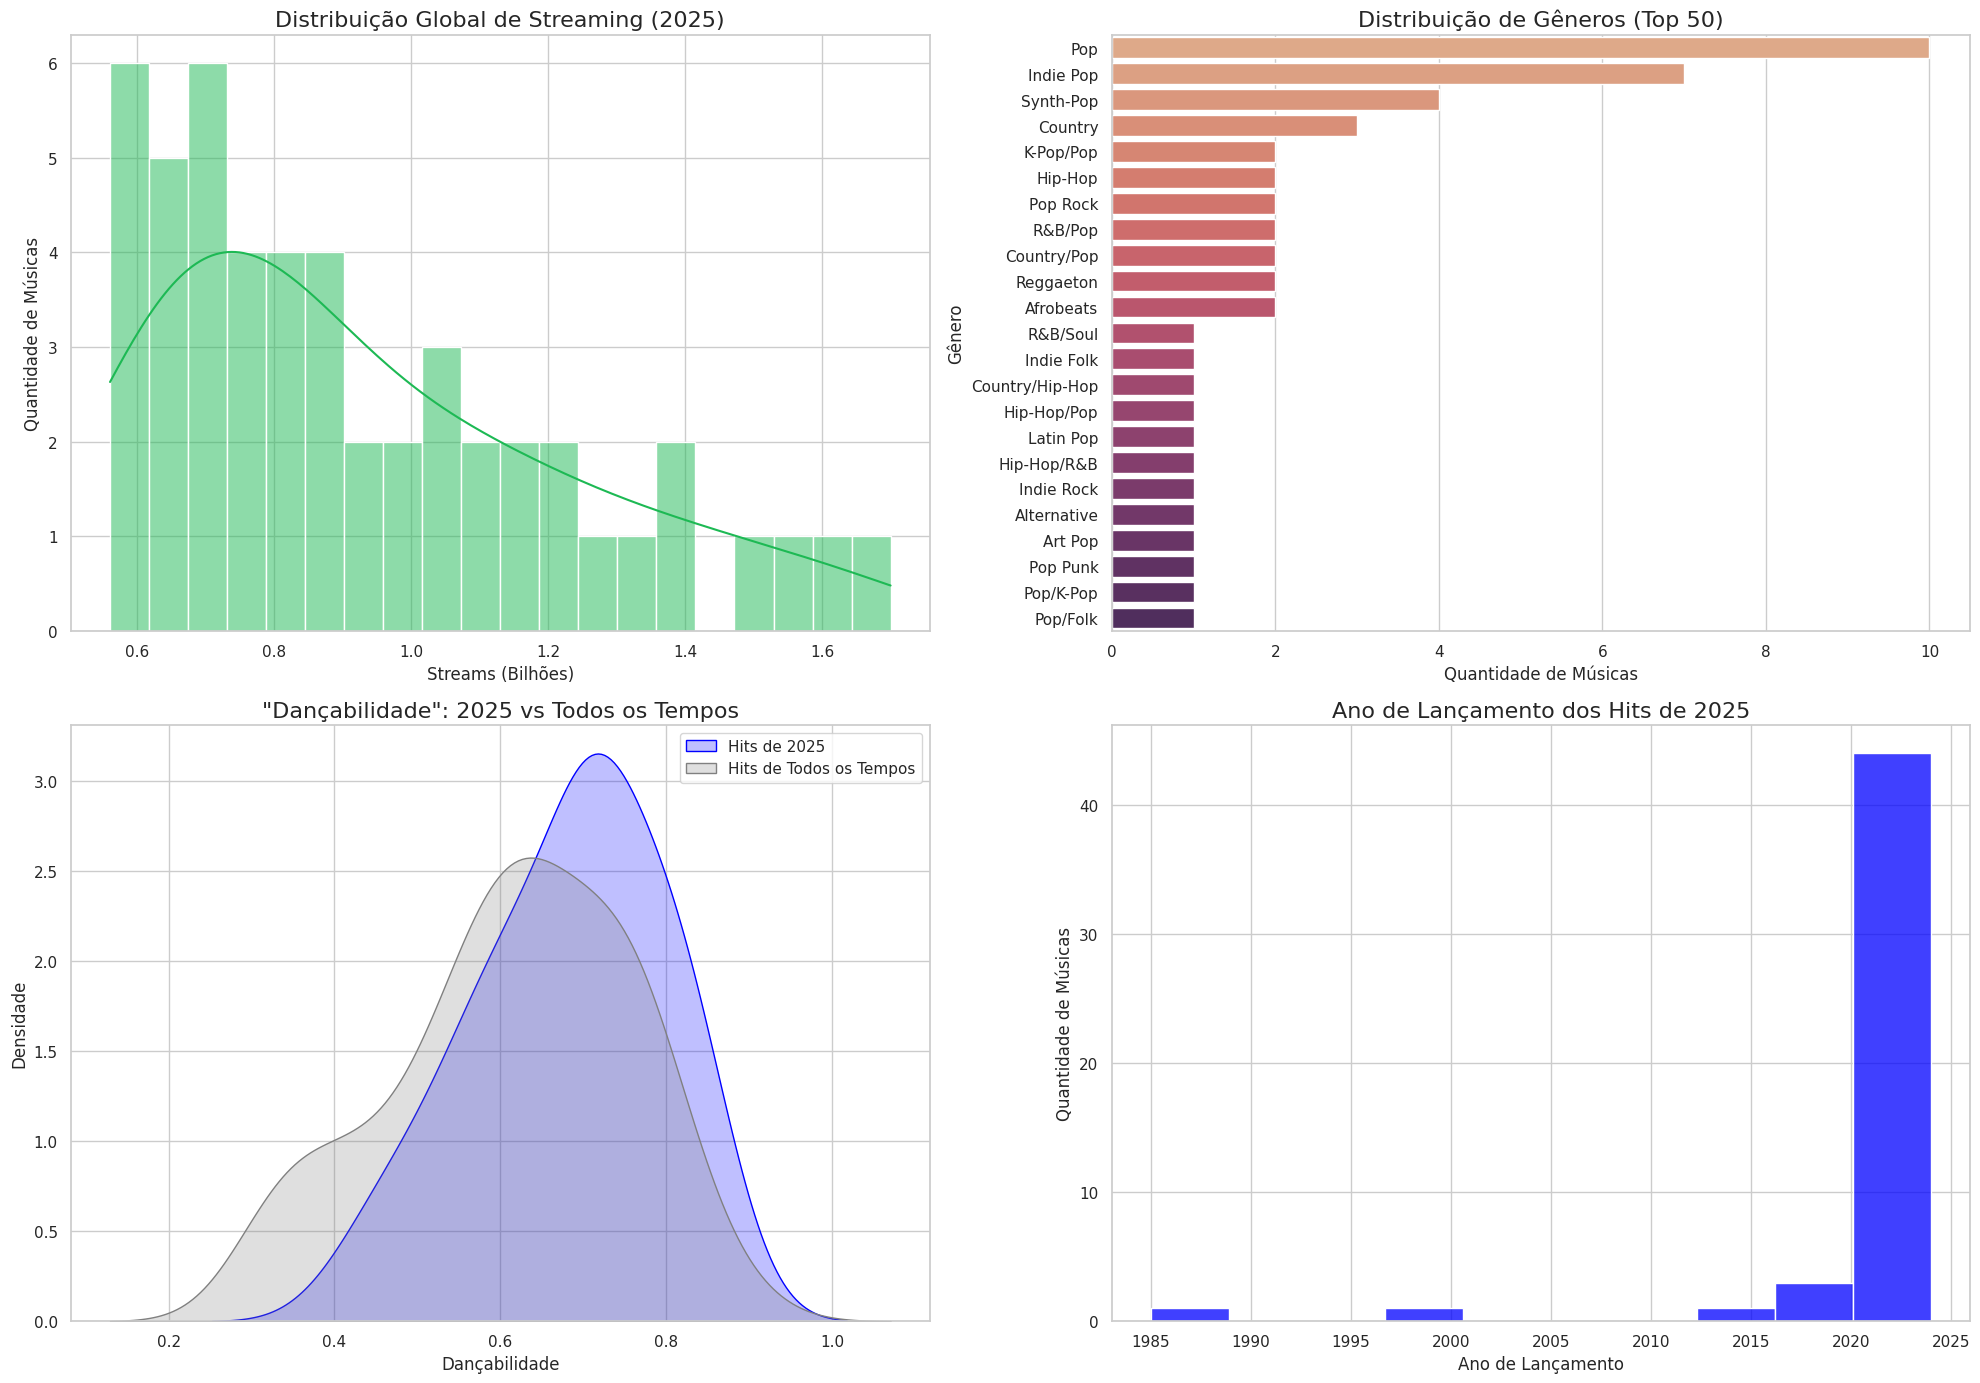

In [30]:

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# A. Distribuição de Streams
sns.histplot(df_musicas_2025['streams_2025_billions'], kde=True, ax=axes[0,0], color='#1DB954', bins=20)
axes[0,0].set_title('Distribuição Global de Streaming (2025)', fontsize=16)
axes[0,0].set_xlabel('Streams (Bilhões)', fontsize=12)

# B. Dominância de Gênero
genre_counts = df_musicas_2025['primary_genre'].value_counts()
sns.barplot(x=genre_counts.values, y=genre_counts.index, ax=axes[0,1], palette='flare')
axes[0,1].set_title('Distribuição de Gêneros (Top 50)', fontsize=16)
axes[0,1].set_xlabel('Quantidade de Músicas', fontsize=12)
axes[0,1].set_ylabel('Gênero', fontsize=12)
axes[0,0].set_ylabel('Quantidade de Músicas', fontsize=12)

# C. "Dançabilidade" vs Todos os Tempos
sns.kdeplot(df_musicas_2025['danceability'], label='Hits de 2025', fill=True, ax=axes[1,0], color='blue')
sns.kdeplot(df_alltime['danceability'], label='Hits de Todos os Tempos', fill=True, ax=axes[1,0], color='gray')
axes[1,0].set_title('"Dançabilidade": 2025 vs Todos os Tempos', fontsize=16)
axes[1,0].set_xlabel('Dançabilidade', fontsize=12)
axes[1,0].set_ylabel('Densidade', fontsize=12)
axes[1,0].legend()

# D. Análise Temporal
sns.histplot(df_musicas_2025['release_year'], ax=axes[1,1], color='blue', bins=10)
axes[1,1].set_title('Ano de Lançamento dos Hits de 2025', fontsize=16)
axes[1,1].set_xlabel('Ano de Lançamento', fontsize=12)
axes[1,1].set_ylabel('Quantidade de Músicas', fontsize=12)
plt.tight_layout()
plt.show()


**Leitura dos gráficos:**
- **Gêneros**: A distribuição é concentrada, com o Pop aparecendo com folga em relação aos demais gêneros primários.
- **Dançabilidade**: A maior densidade está no intervalo `0.6-0.8`, com pico perto de `0.7`, sugerindo preferência por faixas mais rítmicas no recorte de 2025.
- **Hits de 2025**: A maior parte das músicas mais ouvidas foi lançada no próprio ano, indicando forte renovação do catálogo de destaque.

## 5. Visualização e Análise de Artistas

Esta seção analisa a distribuição demográfica e geográfica dos principais artistas de 2025.

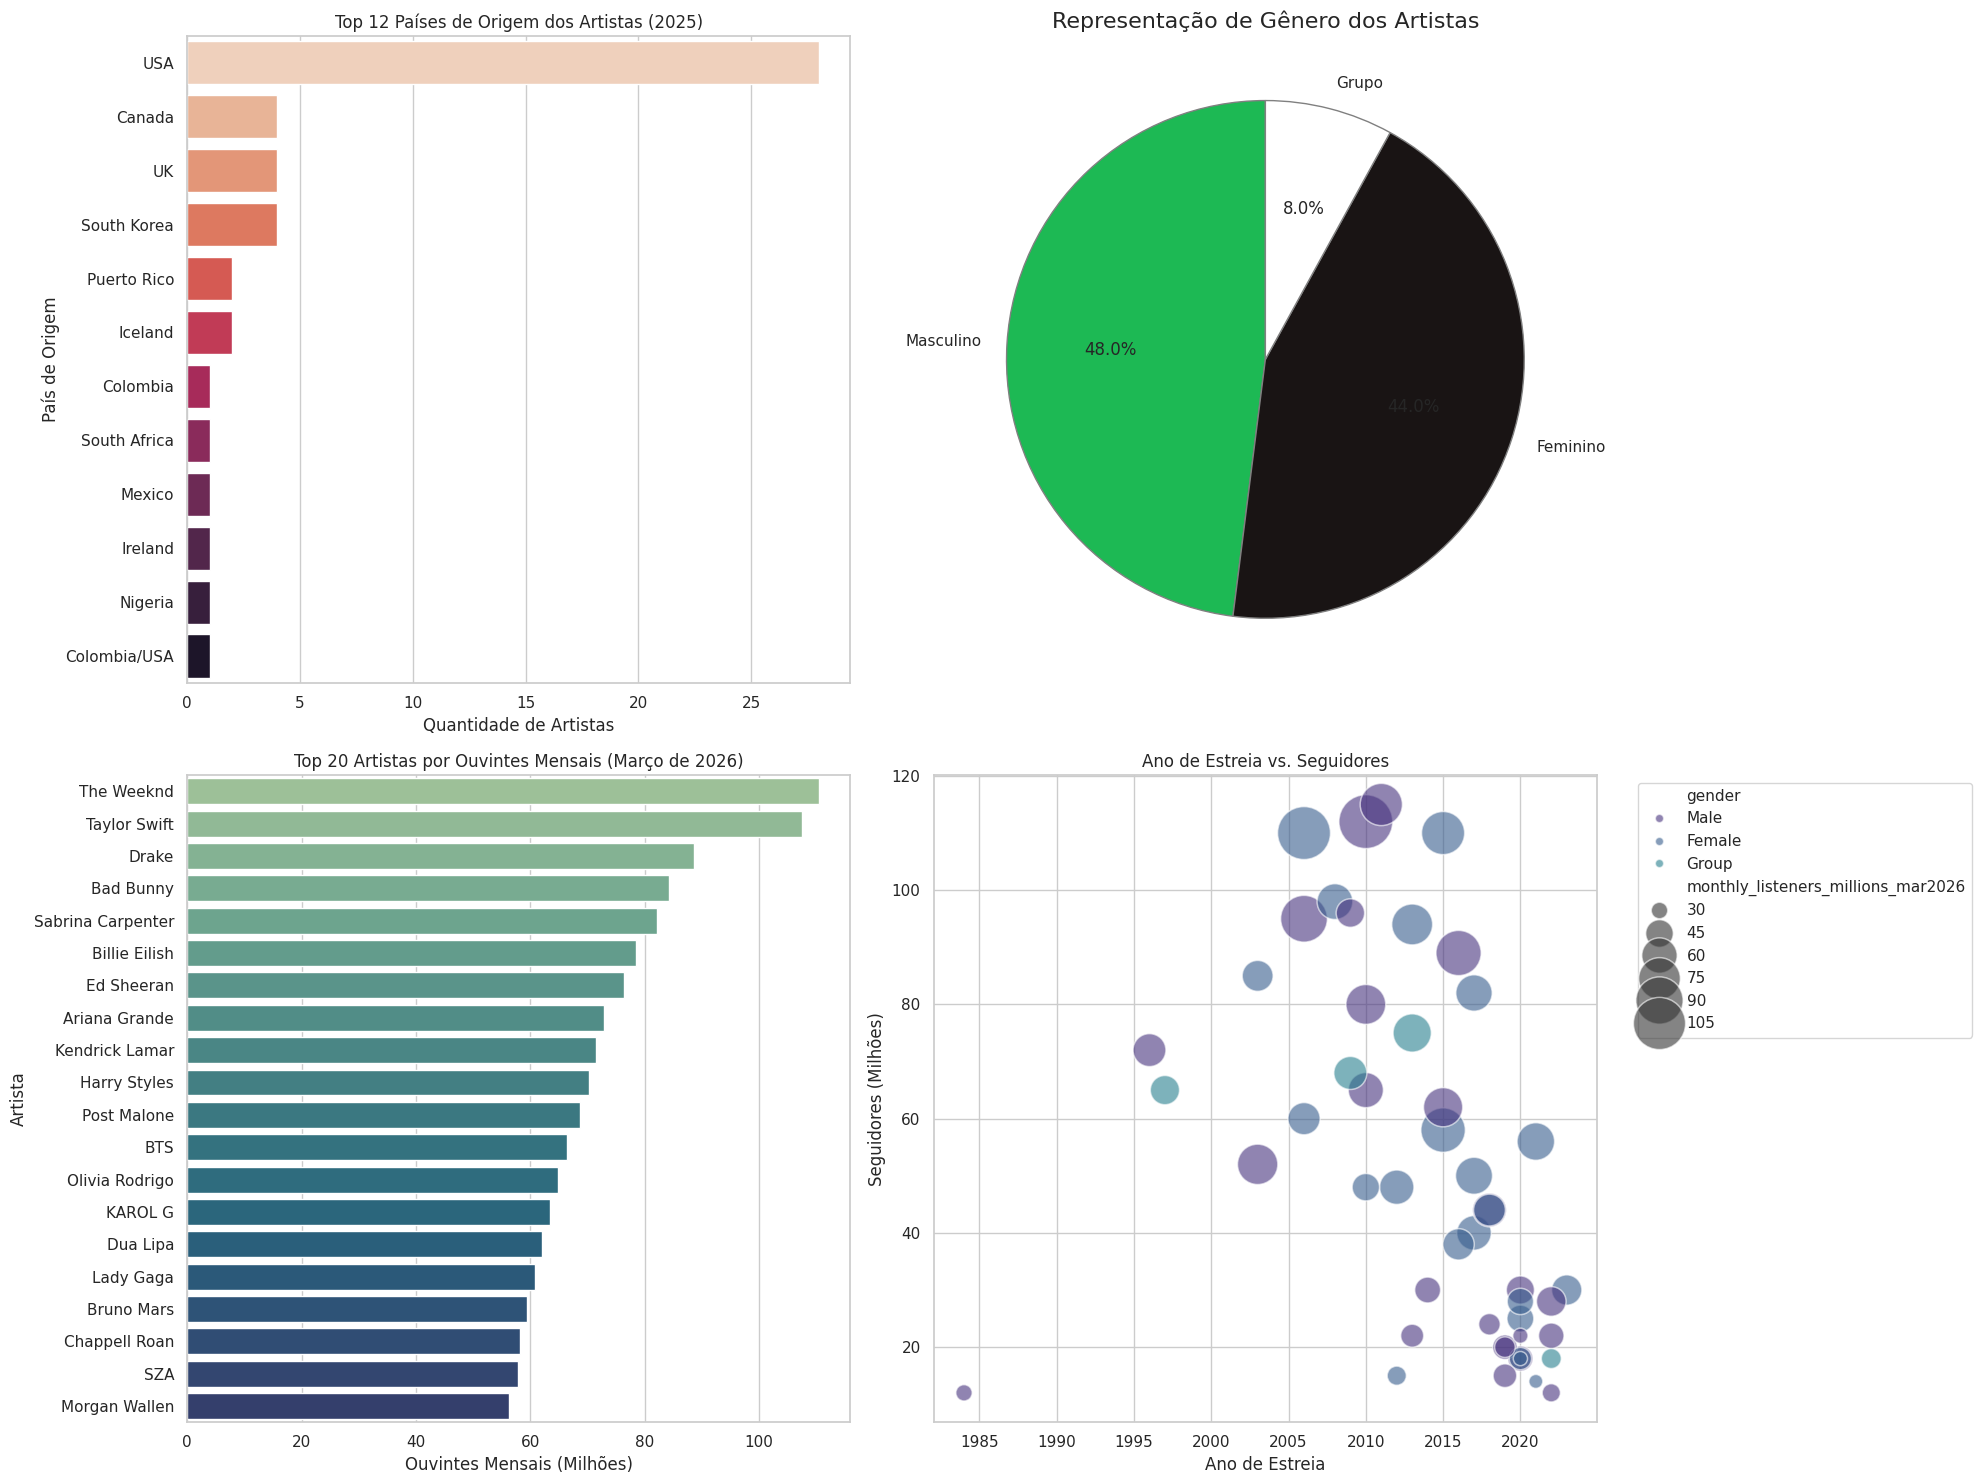

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(20, 15))

# 1. Pegada Geográfica
top_countries = df_artistas_2025['country'].value_counts().head(12)
sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[0,0], palette='rocket_r')
axes[0,0].set(
    title='Top 12 Países de Origem dos Artistas (2025)', 
    ylabel='País de Origem', 
    xlabel='Quantidade de Artistas',
)

# 2. Distribuição por Gênero (Sexo)
mapa_nomes = {
    'Male': 'Masculino',
    'Female': 'Feminino',
    'Group': 'Grupo'
}
gender_dist = df_artistas_2025['gender'].value_counts()
gender_dist = gender_dist.rename(index=mapa_nomes)
axes[0,1].pie(gender_dist, labels=gender_dist.index, autopct='%1.1f%%', startangle=90, 
         colors=['#1db954', '#191414', '#ffffff'], wedgeprops={'edgecolor': 'gray'})
axes[0,1].set_title('Representação de Gênero dos Artistas', fontsize=16)

# 3. Principais Artistas por Volume de Ouvintes
top_names = df_artistas_2025.sort_values('monthly_listeners_millions_mar2026', ascending=False).head(20)
sns.barplot(data=top_names, x='monthly_listeners_millions_mar2026', y='artist_name', ax=axes[1,0], palette='crest')
axes[1,0].set(
    title='Top 20 Artistas por Ouvintes Mensais (Março de 2026)',
    xlabel='Ouvintes Mensais (Milhões)', 
    ylabel='Artista',
)

# 4. Ciclo de Vida do Artista: Estreia na Carreira vs. Popularidade em 2025
sns.scatterplot(data=df_artistas_2025, x='debut_year', y='followers_millions', 
                size='monthly_listeners_millions_mar2026', hue='gender', alpha=0.6, sizes=(100, 1500), ax=axes[1,1])
axes[1,1].set(
    title='Ano de Estreia vs. Seguidores', 
    xlabel='Ano de Estreia', 
    ylabel='Seguidores (Milhões)',
)
axes[1,1].legend(bbox_to_anchor=(1.05, 1), loc=2)

plt.tight_layout()
plt.show()

**Interpretação:**
- **Distribuição por países**: O volume de faixas é desigual entre os países de origem, com forte concentração nos EUA. Isso sugere centralização de mercado, mas o dataset sozinho não permite concluir causalidade.
- **Gênero dos artistas**: A composição entre artistas masculinos e femininos é relativamente próxima, indicando que esse atributo, isoladamente, não explica quem chega ao topo de audiência.

## 6. Correlação e Efeitos de Interação

Análise das interações e das correlações globais entre as características de áudio e o desempenho das músicas.

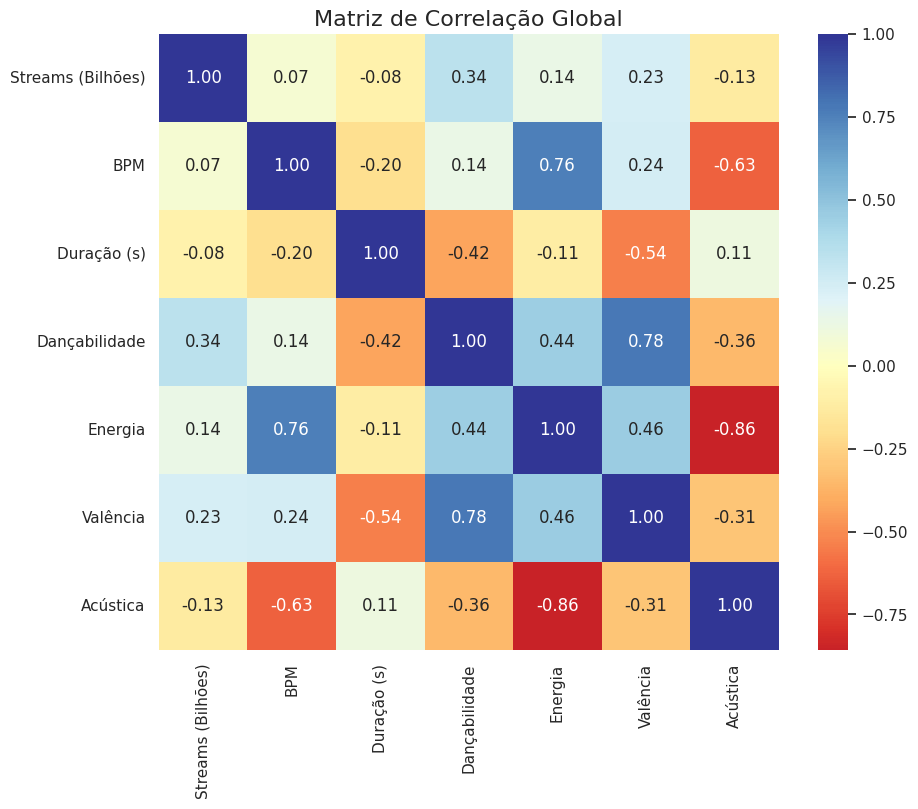

In [32]:

# Mapa de calor de correlação
cols = ['streams_2025_billions', 'bpm', 'duration_seconds', 'danceability', 'energy', 'valence', 'acousticness']
dicionario_nomes = {
    'streams_2025_billions': 'Streams (Bilhões)',
    'bpm': 'BPM',
    'duration_seconds': 'Duração (s)',
    'danceability': 'Dançabilidade',
    'energy': 'Energia',
    'valence': 'Valência',
    'acousticness': 'Acústica'
}
corr = df_musicas_2025[cols].corr()
corr = corr.rename(index=dicionario_nomes, columns=dicionario_nomes)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='RdYlBu', center=0, fmt=".2f")
plt.title('Matriz de Correlação Global', fontsize=16)
plt.show()


## 8. BPM vs Volume de Streams vs Dançabilidade vs Energia

**Objetivo**: Avaliar se variações de BPM se relacionam com volume de streams, dançabilidade e energia.

Nesta seção, o volume de streams funciona como indicador principal de desempenho da faixa.

Termo técnico desta etapa:
- `BPM` (beats per minute): medida de andamento da música, isto é, quantas batidas ocorrem por minuto.

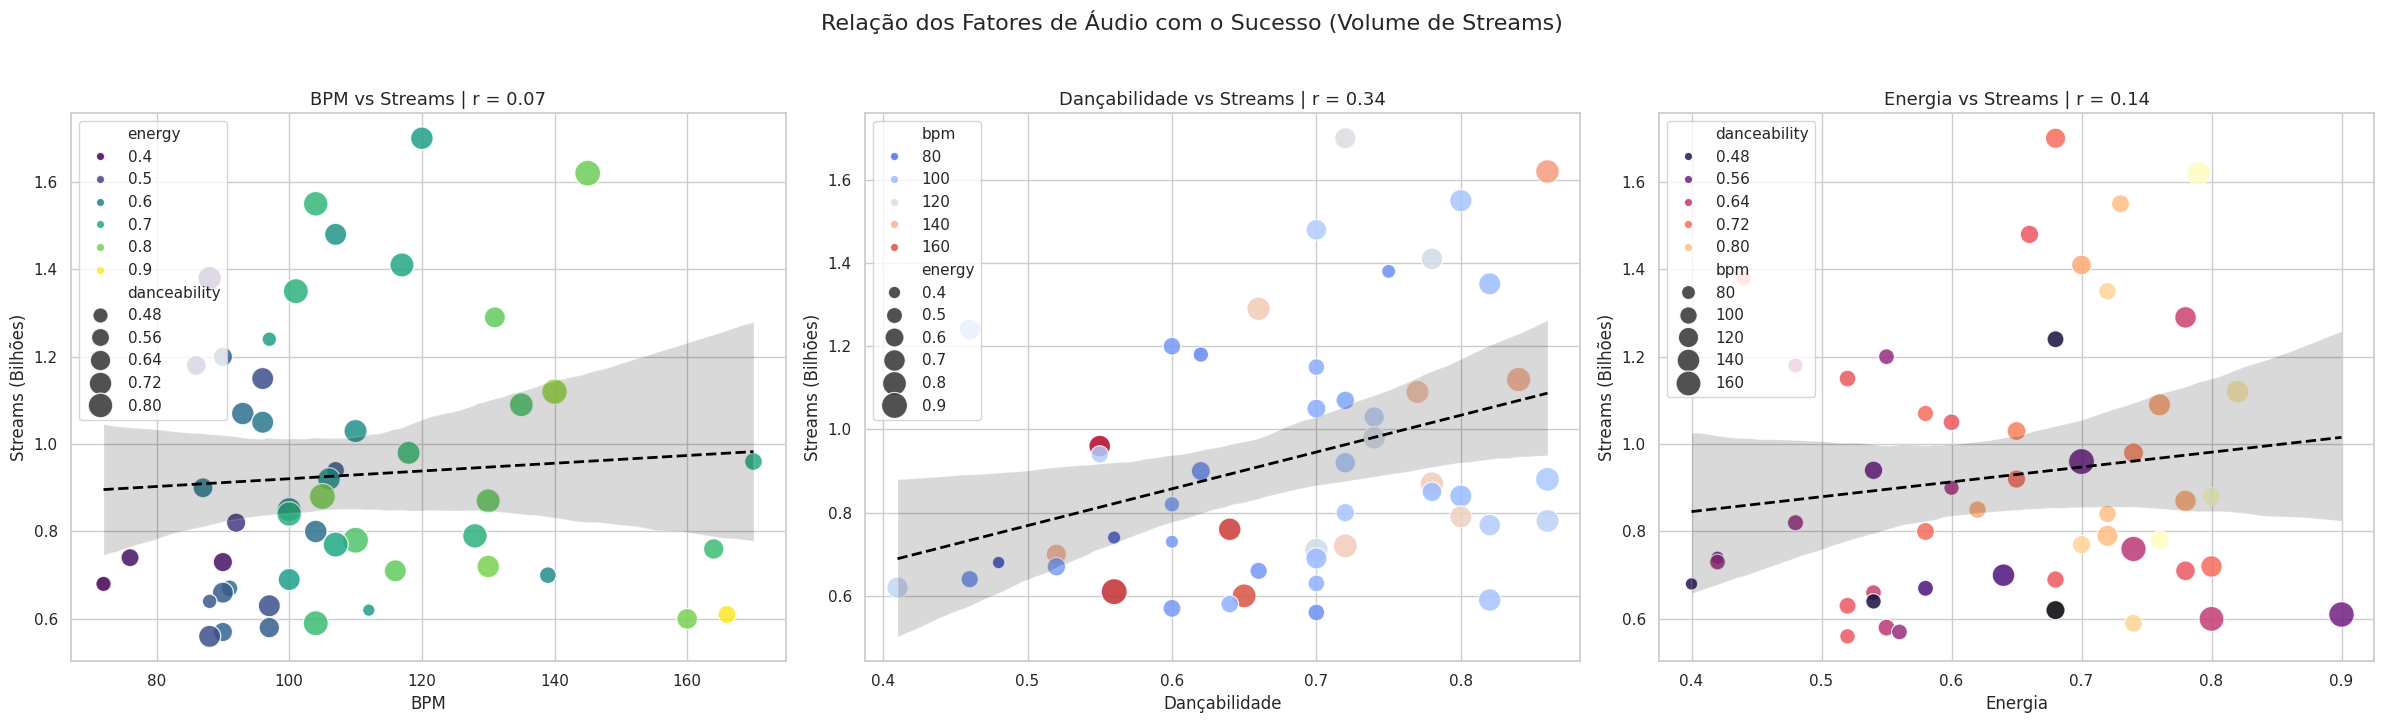

Correlação com Streams (maior valor absoluto = relação linear mais forte):


streams_2025_billions    1.000000
danceability             0.335373
energy                   0.135550
bpm                      0.068360
Name: streams_2025_billions, dtype: float64

In [33]:
# Correlação entre BPM, Streams, Dançabilidade e Energia
dados = df_musicas_2025[['streams_2025_billions', 'bpm', 'danceability', 'energy']].dropna().copy()

# Correlações de Pearson
corr_pearson = dados.corr(method='pearson')

# Coeficientes para usar nos títulos
corr_bpm = corr_pearson.loc['streams_2025_billions', 'bpm']
corr_dance = corr_pearson.loc['streams_2025_billions', 'danceability']
corr_energy = corr_pearson.loc['streams_2025_billions', 'energy']

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Gráfico 1: BPM vs Streams (cor pela energia e tamanho pela dançabilidade)
sns.scatterplot(
    data=dados,
    x='bpm',
    y='streams_2025_billions',
    hue='energy',
    size='danceability',
    palette='viridis',
    sizes=(80, 350),
    alpha=0.85,
    ax=axes[0]
 )
sns.regplot(
    data=dados,
    x='bpm',
    y='streams_2025_billions',
    scatter=False,
    color='black',
    line_kws={'linestyle': '--', 'linewidth': 2},
    ax=axes[0]
 )
axes[0].set_title(f'BPM vs Streams | r = {corr_bpm:.2f}', fontsize=13)
axes[0].set_xlabel('BPM')
axes[0].set_ylabel('Streams (Bilhões)')

# Gráfico 2: Dançabilidade vs Streams (cor pelo BPM e tamanho pela energia)
sns.scatterplot(
    data=dados,
    x='danceability',
    y='streams_2025_billions',
    hue='bpm',
    size='energy',
    palette='coolwarm',
    sizes=(80, 350),
    alpha=0.85,
    ax=axes[1]
 )
sns.regplot(
    data=dados,
    x='danceability',
    y='streams_2025_billions',
    scatter=False,
    color='black',
    line_kws={'linestyle': '--', 'linewidth': 2},
    ax=axes[1]
 )
axes[1].set_title(f'Dançabilidade vs Streams | r = {corr_dance:.2f}', fontsize=13)
axes[1].set_xlabel('Dançabilidade')
axes[1].set_ylabel('Streams (Bilhões)')

# Gráfico 3: Energia vs Streams (cor pela dançabilidade e tamanho pelo BPM)
sns.scatterplot(
    data=dados,
    x='energy',
    y='streams_2025_billions',
    hue='danceability',
    size='bpm',
    palette='magma',
    sizes=(80, 350),
    alpha=0.85,
    ax=axes[2]
 )
sns.regplot(
    data=dados,
    x='energy',
    y='streams_2025_billions',
    scatter=False,
    color='black',
    line_kws={'linestyle': '--', 'linewidth': 2},
    ax=axes[2]
 )
axes[2].set_title(f'Energia vs Streams | r = {corr_energy:.2f}', fontsize=13)
axes[2].set_xlabel('Energia')
axes[2].set_ylabel('Streams (Bilhões)')

plt.suptitle('Relação dos Fatores de Áudio com o Sucesso (Volume de Streams)', fontsize=16, y=1.03)
plt.tight_layout()
plt.show()

# Leitura rápida dos coeficientes com Streams
print('Correlação com Streams (maior valor absoluto = relação linear mais forte):')
display(corr_pearson['streams_2025_billions'].sort_values(ascending=False))

## 9. Modelo Preditivo de Hits

**Objetivo**: Construir um modelo preditivo exploratório para estimar a chance de uma música se tornar hit, considerando características da faixa e, quando disponível, atributos do artista.

**Estratégia**:
- Unificar as músicas de 2025 com o histórico all-time.
- Normalizar o volume de streams dentro de cada fonte para tornar as escalas comparáveis.
- Definir `hit` como músicas no quartil superior de desempenho normalizado.
- Treinar um classificador e gerar exemplos de predição para novas músicas.

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import re

def extrair_artista_principal(nome):
    if pd.isna(nome):
        return np.nan
    return re.split(r'&|ft\.|feat\.|,', str(nome), maxsplit=1)[0].strip().lower()

# Usa os DataFrames já carregados; se o kernel foi reiniciado, recarrega os CSVs
try:
    songs_model = df_musicas_2025.copy()
    artists_model = df_artistas_2025.copy()
    alltime_model = df_alltime.copy()
except NameError:
    songs_model = pd.read_csv('data/spotify_wrapped_2025_top50_songs.csv')
    artists_model = pd.read_csv('data/spotify_wrapped_2025_top50_artists.csv')
    alltime_model = pd.read_csv('data/spotify_alltime_top100_songs.csv')

# Vincula métricas do artista às músicas a partir do artista principal
artists_model['artist_key'] = artists_model['artist_name'].apply(extrair_artista_principal)
songs_model['artist_key'] = songs_model['artist'].apply(extrair_artista_principal)
alltime_model['artist_key'] = alltime_model['artist'].apply(extrair_artista_principal)

artist_features = [
    'artist_key',
    'monthly_listeners_millions_mar2026',
    'followers_millions',
    'grammy_wins',
    'debut_year'
 ]

songs_model = songs_model.merge(artists_model[artist_features], on='artist_key', how='left')
alltime_model = alltime_model.merge(artists_model[artist_features], on='artist_key', how='left')

# Padroniza a métrica de streams e consolida as duas fontes em uma única base
songs_model['stream_metric'] = songs_model['streams_2025_billions']
songs_model['source'] = '2025'
alltime_model['stream_metric'] = alltime_model['total_streams_billions']
alltime_model['source'] = 'alltime'
alltime_model['duration_seconds'] = np.nan

model_cols = [
    'song_title', 'primary_genre', 'bpm', 'duration_seconds', 'release_year',
    'artist_country', 'explicit', 'danceability', 'energy', 'valence',
    'acousticness', 'monthly_listeners_millions_mar2026', 'followers_millions',
    'grammy_wins', 'debut_year', 'stream_metric', 'source'
 ]

base_modelo = pd.concat([
    songs_model[model_cols],
    alltime_model[model_cols]
], ignore_index=True)

base_modelo['explicit'] = base_modelo['explicit'].astype(int)
base_modelo['song_age_2025'] = 2025 - base_modelo['release_year']
base_modelo['stream_percentile_source'] = base_modelo.groupby('source')['stream_metric'].rank(pct=True)
base_modelo['is_hit'] = (base_modelo['stream_percentile_source'] >= 0.75).astype(int)

resumo_base_modelo = pd.DataFrame({
    'indicador': ['total_musicas', 'proporcao_hits', 'fontes_utilizadas'],
    'valor': [
        len(base_modelo),
        round(base_modelo['is_hit'].mean(), 3),
        ', '.join(sorted(base_modelo['source'].unique()))
    ]
})

display(resumo_base_modelo)
display(base_modelo.head())

,indicador,valor
0,total_musicas,150
1,proporcao_hits,0.26
2,fontes_utilizadas,"2025, alltime"


,song_title,primary_genre,bpm,duration_seconds,release_year,artist_country,explicit,danceability,energy,valence,acousticness,monthly_listeners_millions_mar2026,followers_millions,grammy_wins,debut_year,stream_metric,source,song_age_2025,stream_percentile_source,is_hit
0,Die With A Smile,Pop,120,251.0,2024,USA,0,0.72,0.68,0.55,0.18,60.8,98.0,13.0,2008.0,1.70,2025,1,1.00,1
1,APT.,K-Pop/Pop,145,173.0,2024,South Korea,0,0.86,0.79,0.88,0.05,51.8,38.0,0.0,2016.0,1.62,2025,1,0.98,1
2,Espresso,Pop,104,175.0,2024,USA,0,0.80,0.73,0.96,0.06,82.1,58.0,0.0,2015.0,1.55,2025,1,0.96,1
3,Please Please Please,Pop,107,186.0,2024,USA,0,0.70,0.66,0.87,0.10,82.1,58.0,0.0,2015.0,1.48,2025,1,0.94,1
4,Taste,Pop,117,177.0,2024,USA,1,0.78,0.70,0.82,0.08,82.1,58.0,0.0,2015.0,1.41,2025,1,0.92,1


### 9.1 Relação Entre Variáveis e Volume de Streams

Nesta parte, a leitura descritiva mostra como cada variável numérica se comporta em relação ao desempenho relativo em streams dentro de cada fonte (`stream_percentile_source`).

A tabela traz, para cada variável:
- Direção e intensidade da associação (via correlação de Spearman).
- Média entre músicas classificadas como hit.
- Média entre músicas não hit.
- Diferença entre os dois grupos (`delta_hits_vs_demais`).

Termos técnicos desta etapa:
- `Correlação de Spearman`: medida de associação monotônica entre variáveis, baseada em postos.
- `stream_percentile_source`: posição relativa de desempenho da música dentro da própria fonte (2025 ou all-time).

Com isso, fica mais fácil priorizar sinais promissores para a modelagem e orientar próximos passos de engenharia de atributos.

In [35]:
variaveis_numericas = [
    'bpm', 'duration_seconds', 'release_year', 'song_age_2025', 'danceability',
    'energy', 'valence', 'acousticness', 'explicit',
    'monthly_listeners_millions_mar2026', 'followers_millions',
    'grammy_wins', 'debut_year'
 ]

tabela_relacao_streams = pd.DataFrame({
    'variavel': variaveis_numericas,
    'correlacao_spearman_com_streams': [
        base_modelo[[variavel, 'stream_percentile_source']].corr(method='spearman').iloc[0, 1]
        for variavel in variaveis_numericas
    ],
    'media_hits': [
        base_modelo.loc[base_modelo['is_hit'] == 1, variavel].mean()
        for variavel in variaveis_numericas
    ],
    'media_demais_musicas': [
        base_modelo.loc[base_modelo['is_hit'] == 0, variavel].mean()
        for variavel in variaveis_numericas
    ]
})

tabela_relacao_streams['delta_hits_vs_demais'] = (
    tabela_relacao_streams['media_hits'] - tabela_relacao_streams['media_demais_musicas']
 )
tabela_relacao_streams['forca_relacao'] = tabela_relacao_streams['correlacao_spearman_com_streams'].abs()
tabela_relacao_streams = tabela_relacao_streams.sort_values('forca_relacao', ascending=False).drop(columns='forca_relacao')

display(tabela_relacao_streams.round(3))

,variavel,correlacao_spearman_com_streams,media_hits,media_demais_musicas,delta_hits_vs_demais
4,danceability,0.177,0.670,0.624,0.046
9,monthly_listeners_millions_mar2026,0.145,67.494,66.615,0.879
10,followers_millions,0.120,72.419,68.000,4.419
11,grammy_wins,-0.118,3.290,5.897,-2.607
6,valence,0.105,0.631,0.574,0.056
1,duration_seconds,-0.098,205.231,205.514,-0.283
8,explicit,0.097,0.128,0.135,-0.007
2,release_year,0.047,2020.359,2017.829,2.530
3,song_age_2025,-0.047,4.641,7.171,-2.530
7,acousticness,-0.039,0.133,0.160,-0.028


### 9.2 Treinamento do Modelo Preditivo

Aqui, o problema passa a ser de classificação: `is_hit` marca as músicas no quartil superior de desempenho dentro de cada fonte.

O pipeline separa variáveis numéricas e categóricas, aplica imputação, faz padronização quando necessário e treina uma Regressão Logística.

As métricas são lidas assim:
- `accuracy`: percentual total de acertos no teste.
- `roc_auc`: capacidade de separar hits e não hits com base nas probabilidades.
- `taxa_base_hits`: referência mínima da proporção de hits na base.

Esse bloco responde se o modelo já entrega ganho real frente a uma estratégia ingênua e se a separação entre classes é aceitável para uso exploratório.

In [36]:
features = [
    'bpm', 'duration_seconds', 'release_year', 'song_age_2025', 'danceability',
    'energy', 'valence', 'acousticness', 'explicit',
    'monthly_listeners_millions_mar2026', 'followers_millions',
    'grammy_wins', 'debut_year', 'primary_genre', 'artist_country', 'source'
 ]

numeric_features = [
    'bpm', 'duration_seconds', 'release_year', 'song_age_2025', 'danceability',
    'energy', 'valence', 'acousticness', 'explicit',
    'monthly_listeners_millions_mar2026', 'followers_millions',
    'grammy_wins', 'debut_year'
 ]

categorical_features = ['primary_genre', 'artist_country', 'source']

X = base_modelo[features]
y = base_modelo['is_hit']

preprocessador = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_features)
])

modelo_hit = Pipeline([
    ('preprocessador', preprocessador),
    ('classificador', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
 )

modelo_hit.fit(X_train, y_train)

predicoes = modelo_hit.predict(X_test)
probabilidades = modelo_hit.predict_proba(X_test)[:, 1]

metricas_modelo = pd.DataFrame({
    'metrica': ['accuracy', 'roc_auc', 'taxa_base_hits'],
    'valor': [
        accuracy_score(y_test, predicoes),
        roc_auc_score(y_test, probabilidades),
        y.mean()
    ]
})

display(metricas_modelo.round(3))

,metrica,valor
0,accuracy,0.579
1,roc_auc,0.554
2,taxa_base_hits,0.260


### 9.3 Variáveis Mais Influentes no Modelo

Depois do treino, os coeficientes da regressão logística ajudam a entender quais sinais pesam mais na decisão do classificador.

Na tabela:
- `variavel_modelo` identifica a feature após o preprocessamento (incluindo dummies).
- `coeficiente_logistico` mostra direção do efeito no log-odds de hit.
- `impacto_absoluto` ranqueia magnitude de influência.

Termos técnicos desta etapa:
- `Feature`: variável de entrada usada pelo modelo.
- `Dummies`: colunas numéricas (0/1) criadas a partir de categorias.
- `Log-odds`: escala logarítmica das chances (odds) usada na regressão logística.

Essa leitura melhora a explicabilidade do modelo e ajuda a gerar hipóteses de negócio sem confundir associação com causalidade.

In [37]:
feature_names = modelo_hit.named_steps['preprocessador'].get_feature_names_out()
feature_names = pd.Index(feature_names).str.replace('num__', '', regex=False).str.replace('cat__', '', regex=False)
coeficientes = modelo_hit.named_steps['classificador'].coef_[0]

impacto_modelo = pd.DataFrame({
    'variavel_modelo': feature_names,
    'coeficiente_logistico': coeficientes,
    'impacto_absoluto': np.abs(coeficientes)
}).sort_values('impacto_absoluto', ascending=False)

display(impacto_modelo.head(15).round(3))

,variavel_modelo,coeficiente_logistico,impacto_absoluto
11,grammy_wins,-1.123,1.123
47,primary_genre_R&B/Pop,-0.999,0.999
48,primary_genre_R&B/Soul,0.924,0.924
39,primary_genre_Pop Rock,-0.859,0.859
36,primary_genre_Pop,0.852,0.852
61,artist_country_Netherlands,-0.755,0.755
10,followers_millions,0.732,0.732
15,primary_genre_Alt Rock,0.710,0.710
51,primary_genre_Synth-Pop,-0.682,0.682
55,artist_country_Canada/Cuba,0.658,0.658


### 9.4 Simulação de Novas Músicas

Nesta etapa, o modelo é aplicado em faixas hipotéticas para demonstrar aplicação prática.

A saída combina:
- Probabilidade prevista (`chance_de_hit (%)`).
- Rótulo operacional (`Alta chance`, `Chance moderada`, `Baixa chance`).
- Comparação visual em gráfico de barras.

Essa simulação ajuda a comparar cenários antes do lançamento e a discutir estratégias de promoção com um critério quantitativo único.

,exemplo,chance_de_hit (%),classificacao_prevista,bpm,danceability,energy,monthly_listeners_millions_mar2026,followers_millions
0,Faixa Pop Dançante,74.5,Alta chance de hit,128,0.82,0.79,85,70
1,Faixa Indie Intimista,45.7,Chance moderada,92,0.54,0.42,18,9
2,Faixa Urbana Comercial,18.5,Baixa chance,110,0.75,0.67,45,28


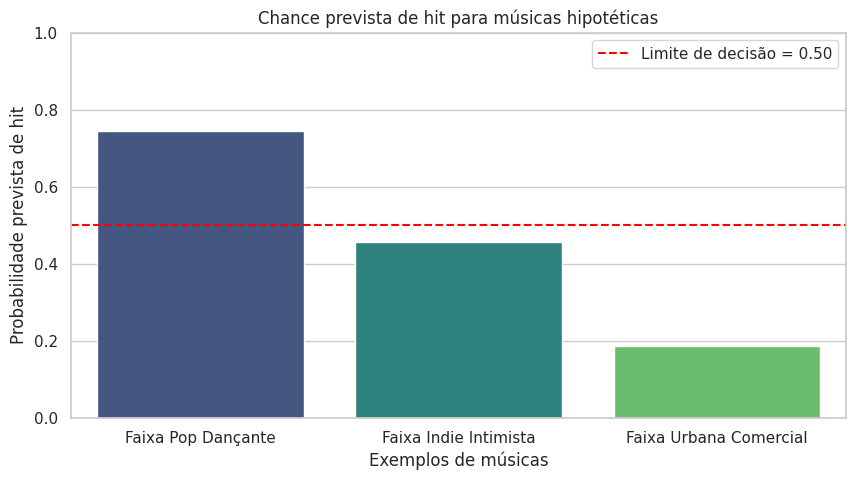

In [38]:
exemplos_musicas = pd.DataFrame([
    {
        'exemplo': 'Faixa Pop Dançante',
        'bpm': 128,
        'duration_seconds': 210,
        'release_year': 2025,
        'danceability': 0.82,
        'energy': 0.79,
        'valence': 0.76,
        'acousticness': 0.08,
        'explicit': 0,
        'monthly_listeners_millions_mar2026': 85,
        'followers_millions': 70,
        'grammy_wins': 4,
        'debut_year': 2014,
        'primary_genre': 'Pop',
        'artist_country': 'USA',
        'source': '2025'
    },
    {
        'exemplo': 'Faixa Indie Intimista',
        'bpm': 92,
        'duration_seconds': 245,
        'release_year': 2025,
        'danceability': 0.54,
        'energy': 0.42,
        'valence': 0.35,
        'acousticness': 0.48,
        'explicit': 0,
        'monthly_listeners_millions_mar2026': 18,
        'followers_millions': 9,
        'grammy_wins': 0,
        'debut_year': 2024,
        'primary_genre': 'Indie Folk',
        'artist_country': 'Brazil',
        'source': '2025'
    },
    {
        'exemplo': 'Faixa Urbana Comercial',
        'bpm': 110,
        'duration_seconds': 195,
        'release_year': 2025,
        'danceability': 0.75,
        'energy': 0.67,
        'valence': 0.61,
        'acousticness': 0.14,
        'explicit': 1,
        'monthly_listeners_millions_mar2026': 45,
        'followers_millions': 28,
        'grammy_wins': 1,
        'debut_year': 2019,
        'primary_genre': 'Hip-Hop/Pop',
        'artist_country': 'USA',
        'source': '2025'
    }
])

exemplos_para_predicao = exemplos_musicas.copy()
exemplos_para_predicao['song_age_2025'] = 2025 - exemplos_para_predicao['release_year']

exemplos_musicas['chance_de_hit'] = modelo_hit.predict_proba(exemplos_para_predicao[features])[:, 1]
exemplos_musicas['chance_de_hit (%)'] = (exemplos_musicas['chance_de_hit'] * 100).round(1)
exemplos_musicas['classificacao_prevista'] = np.select(
    [
        exemplos_musicas['chance_de_hit'] >= 0.70,
        exemplos_musicas['chance_de_hit'] >= 0.40
    ],
    ['Alta chance de hit', 'Chance moderada'],
    default='Baixa chance'
 )

display(exemplos_musicas[[
    'exemplo', 'chance_de_hit (%)', 'classificacao_prevista', 'bpm',
    'danceability', 'energy', 'monthly_listeners_millions_mar2026',
    'followers_millions'
]])

plt.figure(figsize=(10, 5))
sns.barplot(data=exemplos_musicas, x='exemplo', y='chance_de_hit', palette='viridis')
plt.axhline(0.5, color='red', linestyle='--', label='Limite de decisão = 0.50')
plt.ylim(0, 1)
plt.ylabel('Probabilidade prevista de hit')
plt.xlabel('Exemplos de músicas')
plt.title('Chance prevista de hit para músicas hipotéticas')
plt.legend()
plt.show()

### 9.5 Auditoria das Variáveis e Diagnóstico de Qualidade

Esta etapa consolida quais variáveis entram no modelo, verifica a presença de valores ausentes e cria um diagnóstico objetivo do desempenho.

Critérios adotados para avaliar se o resultado é satisfatório no contexto exploratório:
- `roc_auc >= 0.75`: boa capacidade de separação entre hits e não hits.
- `accuracy` acima da `taxa_base_hits`: ganho em relação a uma referência ingênua.
- Diferença positiva de desempenho indica que o modelo agrega valor preditivo.

In [39]:
# Auditoria das variáveis efetivamente usadas no pipeline
requeridas = [
    'features', 'numeric_features', 'categorical_features',
    'X', 'metricas_modelo', 'base_modelo'
 ]
faltantes = [nome for nome in requeridas if nome not in globals()]

if faltantes:
    print('Variáveis ausentes no ambiente. Execute as células 9.2 em diante antes deste bloco.')
    print('Faltantes:', ', '.join(faltantes))
else:
    # 1) Tabela de variáveis usadas e cobertura de nulos na base
    auditoria_variaveis = pd.DataFrame({'variavel': features})
    auditoria_variaveis['tipo'] = auditoria_variaveis['variavel'].apply(
        lambda v: 'numerica' if v in numeric_features else 'categorica'
    )
    auditoria_variaveis['missing_na_base'] = auditoria_variaveis['variavel'].map(X.isna().sum())
    auditoria_variaveis['missing_pct_na_base'] = (
        100 * auditoria_variaveis['missing_na_base'] / len(X)
    ).round(2)

    print('Auditoria das variáveis do modelo:')
    display(auditoria_variaveis.sort_values(['tipo', 'variavel']).reset_index(drop=True))

    # 2) Diagnóstico objetivo de performance
    acc = float(metricas_modelo.loc[metricas_modelo['metrica'] == 'accuracy', 'valor'].iloc[0])
    auc = float(metricas_modelo.loc[metricas_modelo['metrica'] == 'roc_auc', 'valor'].iloc[0])
    base_rate = float(metricas_modelo.loc[metricas_modelo['metrica'] == 'taxa_base_hits', 'valor'].iloc[0])
    lift_accuracy = acc - base_rate

    if auc >= 0.85:
        nivel_auc = 'excelente'
    elif auc >= 0.75:
        nivel_auc = 'bom'
    elif auc >= 0.65:
        nivel_auc = 'moderado'
    else:
        nivel_auc = 'fraco'

    resultado_satisfatorio = (auc >= 0.75) and (lift_accuracy > 0)
    status_final = 'SATISFATORIO (uso exploratorio)' if resultado_satisfatorio else 'NAO SATISFATORIO (requer melhorias)'

    diagnostico_modelo = pd.DataFrame({
        'indicador': [
            'accuracy',
            'roc_auc',
            'taxa_base_hits',
            'lift_accuracy_vs_base',
            'nivel_roc_auc',
            'status_final'
        ],
        'valor': [
            round(acc, 3),
            round(auc, 3),
            round(base_rate, 3),
            round(lift_accuracy, 3),
            nivel_auc,
            status_final
        ]
    })

    print('Diagnóstico de qualidade do modelo:')
    display(diagnostico_modelo)

    # 3) Resumo curto da simulação (se já existir)
    if 'exemplos_musicas' in globals():
        resumo_simulacao = exemplos_musicas[['exemplo', 'chance_de_hit (%)', 'classificacao_prevista']].copy()
        print('Resumo da simulação de músicas hipotéticas:')
        display(resumo_simulacao)

Auditoria das variáveis do modelo:


,variavel,tipo,missing_na_base,missing_pct_na_base
0,artist_country,categorica,0,0.00
1,primary_genre,categorica,0,0.00
2,source,categorica,0,0.00
3,acousticness,numerica,0,0.00
4,bpm,numerica,0,0.00
5,danceability,numerica,0,0.00
6,debut_year,numerica,51,34.00
7,duration_seconds,numerica,100,66.67
8,energy,numerica,0,0.00
9,explicit,numerica,0,0.00


Diagnóstico de qualidade do modelo:


,indicador,valor
0,accuracy,0.579
1,roc_auc,0.554
2,taxa_base_hits,0.26
3,lift_accuracy_vs_base,0.319
4,nivel_roc_auc,fraco
5,status_final,NAO SATISFATORIO (requer melhorias)


Resumo da simulação de músicas hipotéticas:


,exemplo,chance_de_hit (%),classificacao_prevista
0,Faixa Pop Dançante,74.5,Alta chance de hit
1,Faixa Indie Intimista,45.7,Chance moderada
2,Faixa Urbana Comercial,18.5,Baixa chance


### 9.6 Conclusão do Item 9 (Modelo Preditivo)

Juntando as evidências das seções anteriores:
- A seção 9.1 mostra quais atributos se associam ao desempenho relativo.
- A seção 9.2 indica se o classificador supera uma referência simples.
- A seção 9.3 ajuda a entender quais sinais tiveram maior peso no modelo.
- A seção 9.4 traduz esse aprendizado em cenários práticos.

A avaliação final deve considerar o `status_final` da seção 9.5.

Leitura objetiva:
- `SATISFATÓRIO`: o modelo é útil para exploração e simulações iniciais.
- `NÃO SATISFATÓRIO`: o modelo ainda precisa de refinamento (mais dados, novas features e validação mais robusta).

Limites desta análise:
- Base pequena e com fontes heterogêneas.
- Resultado estatístico não implica causalidade.
- Para uso em produção, é necessário validar estabilidade temporal e calibrar threshold conforme o objetivo de negócio.

## 9.7 Melhorias Práticas para Elevar o ROC AUC

**Meta desta etapa:** testar ajustes concretos no pipeline para melhorar a separação entre hits e não hits.

**Plano de trabalho:**
- Comparar modelos com validação cruzada estratificada (`5 folds`).
- Testar configurações de `class_weight` para tratar desbalanceamento.
- Confrontar Regressão Logística e Random Forest no mesmo setup.
- Ajustar o threshold no conjunto de teste e medir impacto operacional.

**Métrica principal:** `roc_auc` médio na validação cruzada.

**Glossário rápido:**
- `Validação cruzada`: repete treino/teste em diferentes partições para reduzir conclusões por acaso.
- `Fold`: cada partição usada em uma rodada da validação cruzada.
- `Estratificada`: preserva proporção de hits e não hits em cada divisão.
- `class_weight`: aumenta o peso da classe minoritária para o modelo prestar mais atenção nela.
- `Regressão Logística`: baseline linear, simples e interpretável.
- `Random Forest`: conjunto de árvores que votam em conjunto.
- `ROC AUC`: mede capacidade de separação; quanto mais perto de `1.0`, melhor.
- `Pipeline`: cadeia única de preprocessamento + modelo, evitando vazamento de dados.
- `Holdout`: conjunto final separado para avaliar generalização.

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
 )
from sklearn.model_selection import StratifiedKFold, cross_validate

requeridas_97 = ['X', 'y', 'numeric_features', 'categorical_features']
faltantes_97 = [v for v in requeridas_97 if v not in globals()]

if faltantes_97:
    print('Variáveis ausentes para a seção 9.7. Execute as células da seção 9.2 primeiro.')
    print('Faltantes:', ', '.join(faltantes_97))
else:
    preprocessor_97 = ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features)
    ])

    configs_modelos = [
        {
            'modelo': 'LogReg | class_weight=None',
            'estimador': LogisticRegression(max_iter=4000, class_weight=None, random_state=42)
        },
        {
            'modelo': 'LogReg | class_weight=balanced',
            'estimador': LogisticRegression(max_iter=4000, class_weight='balanced', random_state=42)
        },
        {
            'modelo': 'LogReg | class_weight={0:1,1:2}',
            'estimador': LogisticRegression(max_iter=4000, class_weight={0: 1, 1: 2}, random_state=42)
        },
        {
            'modelo': 'LogReg | class_weight={0:1,1:3}',
            'estimador': LogisticRegression(max_iter=4000, class_weight={0: 1, 1: 3}, random_state=42)
        },
        {
            'modelo': 'RF | class_weight=None',
            'estimador': RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=1,
                class_weight=None
            )
        },
        {
            'modelo': 'RF | class_weight=balanced',
            'estimador': RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=1,
                class_weight='balanced'
            )
        },
        {
            'modelo': 'RF | class_weight=balanced_subsample',
            'estimador': RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=1,
                class_weight='balanced_subsample'
            )
        }
    ]

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    resultados_cv = []

    for config in configs_modelos:
        pipeline_temp = Pipeline([
            ('preprocessador', preprocessor_97),
            ('classificador', config['estimador'])
        ])

        scores = cross_validate(
            pipeline_temp,
            X, y,
            cv=cv,
            scoring={'roc_auc': 'roc_auc', 'accuracy': 'accuracy'},
            n_jobs=1
        )

        resultados_cv.append({
            'modelo': config['modelo'],
            'roc_auc_cv_media': scores['test_roc_auc'].mean(),
            'roc_auc_cv_std': scores['test_roc_auc'].std(),
            'accuracy_cv_media': scores['test_accuracy'].mean(),
            'accuracy_cv_std': scores['test_accuracy'].std()
        })

    tabela_cv_modelos = pd.DataFrame(resultados_cv).sort_values(
        by='roc_auc_cv_media', ascending=False
    ).reset_index(drop=True)

    melhor_modelo_nome = tabela_cv_modelos.loc[0, 'modelo']
    melhor_config = next(c for c in configs_modelos if c['modelo'] == melhor_modelo_nome)
    melhor_pipeline_97 = Pipeline([
        ('preprocessador', preprocessor_97),
        ('classificador', melhor_config['estimador'])
    ])

    print('Comparação por validação cruzada (ordem por ROC AUC):')
    display(tabela_cv_modelos.round(4))
    print(f"Melhor candidato por ROC AUC médio: {melhor_modelo_nome}")

Comparação por validação cruzada (ordem por ROC AUC):


,modelo,roc_auc_cv_media,roc_auc_cv_std,accuracy_cv_media,accuracy_cv_std
0,RF | class_weight=balanced,0.5858,0.1028,0.6933,0.0646
1,RF | class_weight=balanced_subsample,0.5844,0.1003,0.6867,0.0581
2,RF | class_weight=None,0.5806,0.0792,0.6867,0.0653
3,LogReg | class_weight=balanced,0.5327,0.1634,0.5533,0.1258
4,"LogReg | class_weight={0:1,1:3}",0.5316,0.1543,0.5533,0.1258
5,"LogReg | class_weight={0:1,1:2}",0.5282,0.1605,0.6000,0.1011
6,LogReg | class_weight=None,0.5249,0.1729,0.6533,0.1002


Melhor candidato por ROC AUC médio: RF | class_weight=balanced


### 9.7.1 Ajuste de Threshold e Comparação no Holdout

Com o melhor candidato da validação cruzada, o treinamento foi realizado no conjunto de treino e o desempenho foi medido no teste (holdout).

Pontos-chave desta etapa:
- O `ROC AUC` avalia separação e não depende de threshold.
- O threshold altera o comportamento operacional (`f1`, `recall`, `precision`).
- A comparação entre `0.50` e threshold ajustado evidencia o trade-off da decisão.

Resumo rápido dos termos:
- `Threshold`: limite para classificar como hit.
- `Precision`: entre os previstos como hit, quantos eram hit.
- `Recall`: entre os hits reais, quantos foram encontrados.
- `F1`: equilíbrio entre precision e recall.
- `Balanced accuracy`: média de acerto entre as duas classes.

ROC AUC no holdout (melhor candidato): 0.461
Top 10 thresholds por F1:


,threshold,accuracy,balanced_accuracy,precision,recall,f1
0,0.20,0.3421,0.5214,0.2727,0.9,0.4186
1,0.30,0.5526,0.5679,0.3158,0.6,0.4138
2,0.24,0.4211,0.5107,0.2692,0.7,0.3889
3,0.28,0.5000,0.5321,0.2857,0.6,0.3871
4,0.36,0.5789,0.5536,0.3125,0.5,0.3846
5,0.34,0.5526,0.5357,0.2941,0.5,0.3704
6,0.26,0.4474,0.4964,0.2609,0.6,0.3636
7,0.22,0.3421,0.4571,0.2414,0.7,0.3590
8,0.32,0.5263,0.5179,0.2778,0.5,0.3571
9,0.38,0.5526,0.5036,0.2667,0.4,0.3200


Comparativo operacional: threshold padrão vs tunado


,cenario,accuracy,balanced_accuracy,precision,recall,f1,roc_auc_probabilidades
0,threshold_0.50,0.7105,0.4821,0.0000,0.0,0.0000,0.4607
1,threshold_melhorado_0.20,0.3421,0.5214,0.2727,0.9,0.4186,0.4607


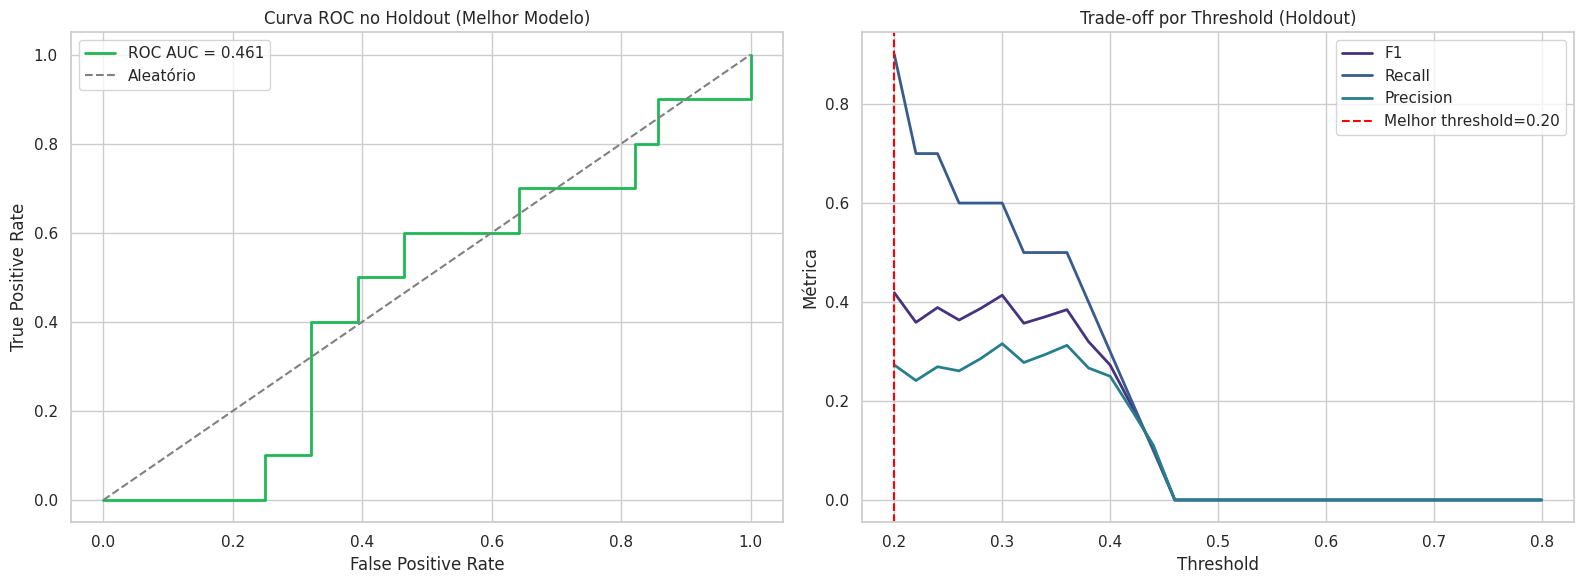

In [41]:
if 'melhor_pipeline_97' not in globals():
    print('Execute a célula anterior da seção 9.7 para gerar o melhor modelo.')
else:
    X_train_97, X_test_97, y_train_97, y_test_97 = train_test_split(
        X, y,
        test_size=0.25,
        random_state=42,
        stratify=y
    )

    melhor_pipeline_97.fit(X_train_97, y_train_97)
    prob_test_97 = melhor_pipeline_97.predict_proba(X_test_97)[:, 1]

    roc_auc_teste_97 = roc_auc_score(y_test_97, prob_test_97)

    thresholds_grid = np.arange(0.20, 0.81, 0.02)
    tabela_threshold = []

    for thr in thresholds_grid:
        pred_thr = (prob_test_97 >= thr).astype(int)
        tabela_threshold.append({
            'threshold': thr,
            'accuracy': accuracy_score(y_test_97, pred_thr),
            'balanced_accuracy': balanced_accuracy_score(y_test_97, pred_thr),
            'precision': precision_score(y_test_97, pred_thr, zero_division=0),
            'recall': recall_score(y_test_97, pred_thr, zero_division=0),
            'f1': f1_score(y_test_97, pred_thr, zero_division=0)
        })

    tabela_threshold = pd.DataFrame(tabela_threshold).sort_values('f1', ascending=False).reset_index(drop=True)
    melhor_thr = float(tabela_threshold.loc[0, 'threshold'])

    pred_05 = (prob_test_97 >= 0.50).astype(int)
    pred_tuned = (prob_test_97 >= melhor_thr).astype(int)

    comparativo_threshold = pd.DataFrame({
        'cenario': ['threshold_0.50', f'threshold_melhorado_{melhor_thr:.2f}'],
        'accuracy': [
            accuracy_score(y_test_97, pred_05),
            accuracy_score(y_test_97, pred_tuned)
        ],
        'balanced_accuracy': [
            balanced_accuracy_score(y_test_97, pred_05),
            balanced_accuracy_score(y_test_97, pred_tuned)
        ],
        'precision': [
            precision_score(y_test_97, pred_05, zero_division=0),
            precision_score(y_test_97, pred_tuned, zero_division=0)
        ],
        'recall': [
            recall_score(y_test_97, pred_05, zero_division=0),
            recall_score(y_test_97, pred_tuned, zero_division=0)
        ],
        'f1': [
            f1_score(y_test_97, pred_05, zero_division=0),
            f1_score(y_test_97, pred_tuned, zero_division=0)
        ],
        'roc_auc_probabilidades': [roc_auc_teste_97, roc_auc_teste_97]
    })

    print(f'ROC AUC no holdout (melhor candidato): {roc_auc_teste_97:.3f}')
    print('Top 10 thresholds por F1:')
    display(tabela_threshold.head(10).round(4))
    print('Comparativo operacional: threshold padrão vs tunado')
    display(comparativo_threshold.round(4))

    fpr_97, tpr_97, _ = roc_curve(y_test_97, prob_test_97)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Curva ROC
    axes[0].plot(fpr_97, tpr_97, color='#1DB954', linewidth=2, label=f'ROC AUC = {roc_auc_teste_97:.3f}')
    axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Aleatório')
    axes[0].set_title('Curva ROC no Holdout (Melhor Modelo)')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].legend()

    # Curvas de métricas por threshold
    metricas_plot = tabela_threshold.sort_values('threshold')
    axes[1].plot(metricas_plot['threshold'], metricas_plot['f1'], label='F1', linewidth=2)
    axes[1].plot(metricas_plot['threshold'], metricas_plot['recall'], label='Recall', linewidth=2)
    axes[1].plot(metricas_plot['threshold'], metricas_plot['precision'], label='Precision', linewidth=2)
    axes[1].axvline(melhor_thr, color='red', linestyle='--', label=f'Melhor threshold={melhor_thr:.2f}')
    axes[1].set_title('Trade-off por Threshold (Holdout)')
    axes[1].set_xlabel('Threshold')
    axes[1].set_ylabel('Métrica')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

### 9.7.2 Conclusão da Rodada de Melhoria

Nesta rodada, a leitura principal é:
- A validação cruzada aponta a combinação `modelo + class_weight` mais consistente em separação.
- O holdout confirma (ou não) se esse ganho se sustenta fora do treino.
- O ajuste de threshold melhora o uso prático, mas não altera o ROC AUC em si.

Faixas de interpretação sugeridas:
- **Satisfatório**: ROC AUC no holdout perto ou acima de `0.70`, com ganho operacional claro.
- **Parcialmente satisfatório**: ROC AUC entre `0.60` e `0.70`, útil para exploração, mas com instabilidade.
- **Não satisfatório**: ROC AUC abaixo de `0.60`, pedindo novas features, mais dados e ajustes adicionais.

Em resumo, threshold tuning é ajuste de decisão; melhora estrutural depende de melhor separação no holdout.

### 9.7.3 Interpretação Factual dos Resultados

Esta subseção consolida três perguntas:
- Qual modelo venceu na validação cruzada?
- O ganho de separação apareceu no holdout?
- Como o threshold tuning afetou as métricas operacionais?

Guia de leitura da tabela final:
- `ROC AUC médio no CV`: desempenho médio nas rodadas de validação.
- `ROC AUC no holdout`: desempenho em dados separados (mais próximo do cenário real).
- `Gap holdout - CV`: diferença entre os dois resultados; gap negativo pode indicar perda de generalização.
- `F1 @0.50` vs `F1 @threshold_melhorado`: mostra se houve melhora no equilíbrio entre capturar hits e evitar falsos positivos.
- `Status final`: síntese objetiva da qualidade da rodada de melhoria.

In [42]:
requeridas_973 = [
    'tabela_cv_modelos', 'melhor_modelo_nome', 'roc_auc_teste_97',
    'comparativo_threshold', 'tabela_threshold'
 ]
faltantes_973 = [v for v in requeridas_973 if v not in globals()]

if faltantes_973:
    print('Execute as células 9.7 e 9.7.1 antes deste bloco.')
    print('Faltantes:', ', '.join(faltantes_973))
else:
    roc_auc_cv_top = float(tabela_cv_modelos.loc[0, 'roc_auc_cv_media'])
    roc_auc_cv_gap = roc_auc_teste_97 - roc_auc_cv_top

    f1_05 = float(comparativo_threshold.loc[comparativo_threshold['cenario'] == 'threshold_0.50', 'f1'].iloc[0])
    f1_tuned = float(comparativo_threshold.loc[comparativo_threshold['cenario'].str.contains('threshold_melhorado'), 'f1'].iloc[0])
    recall_05 = float(comparativo_threshold.loc[comparativo_threshold['cenario'] == 'threshold_0.50', 'recall'].iloc[0])
    recall_tuned = float(comparativo_threshold.loc[comparativo_threshold['cenario'].str.contains('threshold_melhorado'), 'recall'].iloc[0])
    acc_05 = float(comparativo_threshold.loc[comparativo_threshold['cenario'] == 'threshold_0.50', 'accuracy'].iloc[0])
    acc_tuned = float(comparativo_threshold.loc[comparativo_threshold['cenario'].str.contains('threshold_melhorado'), 'accuracy'].iloc[0])

    if roc_auc_teste_97 >= 0.70:
        status_97 = 'SATISFATORIO'
    elif roc_auc_teste_97 >= 0.60:
        status_97 = 'PARCIALMENTE SATISFATORIO'
    else:
        status_97 = 'NAO SATISFATORIO'

    interpretacao_97 = pd.DataFrame({
        'topico': [
            'Melhor modelo na validacao cruzada',
            'ROC AUC medio no CV (melhor modelo)',
            'ROC AUC no holdout',
            'Gap holdout - CV',
            'F1 @0.50',
            'F1 @threshold_melhorado',
            'Recall @0.50',
            'Recall @threshold_melhorado',
            'Accuracy @0.50',
            'Accuracy @threshold_melhorado',
            'Status final da rodada 9.7'
        ],
        'valor': [
            melhor_modelo_nome,
            round(roc_auc_cv_top, 4),
            round(roc_auc_teste_97, 4),
            round(roc_auc_cv_gap, 4),
            round(f1_05, 4),
            round(f1_tuned, 4),
            round(recall_05, 4),
            round(recall_tuned, 4),
            round(acc_05, 4),
            round(acc_tuned, 4),
            status_97
        ]
    })

    print('Leitura factual consolidada da secao 9.7:')
    display(interpretacao_97)

    print('Resumo analitico:')
    if roc_auc_teste_97 < 0.60:
        print('- A melhoria de modelo/ponderacao nao foi suficiente para boa separacao no holdout.')
    else:
        print('- Houve sinal de melhora de separacao no holdout.')

    if f1_tuned > f1_05:
        print('- O tuning de threshold melhorou F1 e favoreceu captura de hits (recall maior).')
    else:
        print('- O tuning de threshold não melhorou F1 de forma relevante.')

    if acc_tuned < acc_05:
        print('- O ganho em recall ocorreu com perda de accuracy, indicando trade-off.')

Leitura factual consolidada da secao 9.7:


,topico,valor
0,Melhor modelo na validacao cruzada,RF | class_weight=balanced
1,ROC AUC medio no CV (melhor modelo),0.5858
2,ROC AUC no holdout,0.4607
3,Gap holdout - CV,-0.1251
4,F1 @0.50,0.0
5,F1 @threshold_melhorado,0.4186
6,Recall @0.50,0.0
7,Recall @threshold_melhorado,0.9
8,Accuracy @0.50,0.7105
9,Accuracy @threshold_melhorado,0.3421


Resumo analitico:
- A melhoria de modelo/ponderacao nao foi suficiente para boa separacao no holdout.
- O tuning de threshold melhorou F1 e favoreceu captura de hits (recall maior).
- O ganho em recall ocorreu com perda de accuracy, indicando trade-off.
